In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [ ]:
df = pd.read_csv("employee.csv")
df.head()
df.shape
df.info()
df.describe()
df.columns
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

np.int64(0)

In [ ]:
df_clean = df.copy()

In [ ]:
df_clean.drop_duplicates(inplace=True)
df_clean.shape
df_clean.columns = df_clean.columns.str.lower()
df_clean.columns
df_clean.to_csv("cleaned_employee_data.csv",index=False)

In [ ]:
conn = sqlite3.connect("employee_attrition.db")

In [ ]:
df_clean.to_sql(
    "employees",
    conn,
    if_exists="replace",
    index=False
)

1470

In [ ]:
query = """
SELECT COUNT(*)
FROM employees
"""

pd.read_sql(query,conn)

,COUNT(*)
0,1470


In [ ]:
query = """
SELECT age,
department,
monthlyincome
FROM employees
WHERE age > 40
"""
pd.read_sql(query,conn)

,age,department,monthlyincome
0,41,Sales,5993
1,49,Research & Development,5130
2,59,Research & Development,2670
3,53,Sales,15427
4,53,Research & Development,19094
...,...,...,...
460,41,Sales,8938
461,50,Sales,6728
462,45,Sales,4850
463,50,Sales,10854


In [ ]:
query = """
SELECT age,
monthlyincome
FROM employees
ORDER BY monthlyincome DESC
LIMIT 10
"""
pd.read_sql(query,conn)

,age,monthlyincome
0,52,19999
1,41,19973
2,56,19943
3,50,19926
4,55,19859
5,51,19847
6,52,19845
7,40,19833
8,43,19740
9,56,19717


In [ ]:
query = """
SELECT AVG(monthlyincome)
AS average_salary
FROM employees
"""
pd.read_sql(query,conn)

,average_salary
0,6502.931293


In [ ]:
query = """
SELECT department,
COUNT(*) AS total_employees
FROM employees
GROUP BY department
"""
pd.read_sql(query,conn)

,department,total_employees
0,Human Resources,63
1,Research & Development,961
2,Sales,446


In [ ]:
query = """
SELECT age,
jobrole,
monthlyincome
FROM employees
WHERE monthlyincome > 10000
AND yearsatcompany > 5
"""
pd.read_sql(query,conn)

,age,jobrole,monthlyincome
0,53,Manager,15427
1,34,Research Director,11994
2,53,Manager,19094
3,44,Healthcare Representative,10248
4,41,Research Director,19545
...,...,...,...
197,37,Research Director,13744
198,39,Manager,19431
199,42,Manager,18880
200,41,Manufacturing Director,13570


In [ ]:
query = """
SELECT *,
CASE
WHEN age < 30
THEN 'Young'

WHEN age BETWEEN 30 AND 45
THEN 'Middle Age'

ELSE 'Senior'
END AS age_group

FROM employees
"""
transformed_df = pd.read_sql(query,conn)

In [ ]:
query = """
SELECT *,

CASE
WHEN monthlyincome >= 10000
THEN 'High Income'

ELSE 'Regular Income'

END AS income_category

FROM employees
"""
transformed_df = pd.read_sql(query,conn)

In [ ]:
transformed_df.to_csv(
    "transformed_employee_data.csv",
    index=False
)

In [ ]:
def extract():

    data = pd.read_csv(
        "employee.csv"
    )

    return data

In [ ]:
def transform(data):

    data.drop_duplicates(inplace=True)

    data.columns = data.columns.str.lower()

    return data

In [ ]:
def load(data):

    data.to_csv(
        "etl_output.csv",
        index=False
    )

    print("Loaded Successfully")

In [ ]:
data = extract()
data = transform(data)
load(data)

Loaded Successfully


In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Capstone") \
    .getOrCreate()

In [ ]:
bronze_df = spark.read.csv(
    "employee.csv",
    header=True,
    inferSchema=True
)
bronze_df.write.mode(
    "overwrite"
).parquet("bronze")

In [ ]:
silver_df = bronze_df.dropDuplicates()
silver_df = silver_df.na.drop()
silver_df.write.mode(
    "overwrite"
).parquet("silver")

In [ ]:
from pyspark.sql.functions import avg
gold_df = silver_df.groupBy(
    "Department"
).agg(
    avg("MonthlyIncome").alias(
        "AverageSalary"
    )
)
gold_df.write.mode(
    "overwrite"
).parquet("gold")

In [ ]:
comparison = pd.DataFrame({

"Feature":[
"File Size",
"Storage Efficiency",
"Read Speed",
"Write Speed",
"Compression"
],

"CSV":[
"Large",
"Low",
"Slow",
"Moderate",
"No"
],

"Parquet":[
"Small",
"High",
"Fast",
"Fast",
"Yes"
]

})

comparison

,Feature,CSV,Parquet
0,File Size,Large,Small
1,Storage Efficiency,Low,High
2,Read Speed,Slow,Fast
3,Write Speed,Moderate,Fast
4,Compression,No,Yes


In [ ]:
gold_parquet = spark.read.parquet(
    "gold"
)
gold_pandas = gold_parquet.toPandas()

gold_pandas.head()

,Department,AverageSalary
0,Sales,6959.172646
1,Research & Development,6281.252862
2,Human Resources,6654.507937


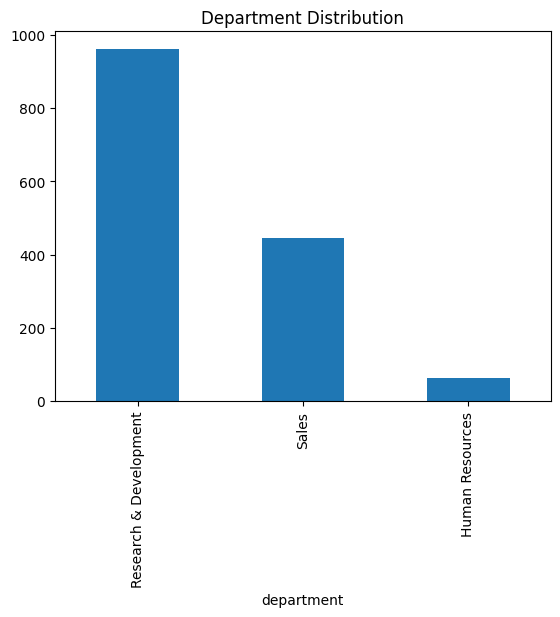

In [ ]:
df_clean['department'].value_counts().plot(
    kind='bar'
)
plt.title("Department Distribution")
plt.show()

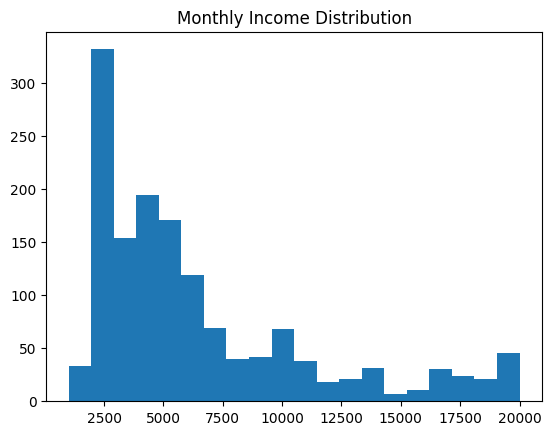

In [ ]:
plt.hist(
    df_clean['monthlyincome'],
    bins=20
)
plt.title("Monthly Income Distribution")
plt.show()

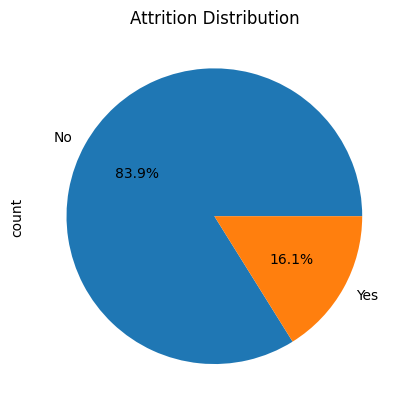

In [ ]:
df_clean['attrition'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Attrition Distribution")
plt.show()